In [1]:
import matplotlib.pyplot as plt

from fenics import Function, plot
from utils.colors import CMAP
from utils.problem_setup import TestProblemsSetup

#from algorithms.dynamical_low_rank_solver import DynamicalLowRankSolver
from algorithms.cg_solvers import DynamicalLowRankCG, DynamicalLowRankApproximation
from algorithms.rsvd_solvers import MatrixFreeRSVD

PROBLEMS = TestProblemsSetup(n=64).get_test_problems()
SEED = 15

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [8]:
f_list = []
max_ranks = [1, 2]

pid = 'I'
pb = PROBLEMS[pid]

rsvd = MatrixFreeRSVD(pb['V_h'])
rsvd.solve(k=50)
w = rsvd.weights()

def as_func(x, V_h):
    f = Function(V_h)
    f.vector()[:] = x
    return f

# DLRA solution
solver_dlra = DynamicalLowRankApproximation(rsvd)
x_dlra = solver_dlra.solve(
    pb['y'], w,
    lambda_=1e-4,
    max_rank=1,
    rtol=1e-4,
    verbose=True,
    max_iter=5_000
)
f_dlra = as_func(x_dlra, pb['V_h'])

# DLR-CG solution
solver_cg = DynamicalLowRankCG(rsvd)
x_cg = solver_cg.solve(
    pb['y'], w,
    lambda_=1e-4,
    max_rank=1,
    rtol=1e-8,
    verbose=True,
    max_iter=5_000
)
f_cg = as_func(x_cg, pb['V_h'])

[##############################] 5000/5000
Converged at iter 135 [rel_res=9.83e-09]0


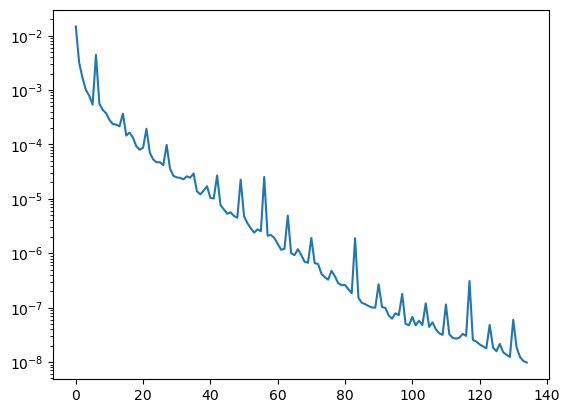

In [11]:
plt.semilogy(solver_cg.residual)
plt.show()

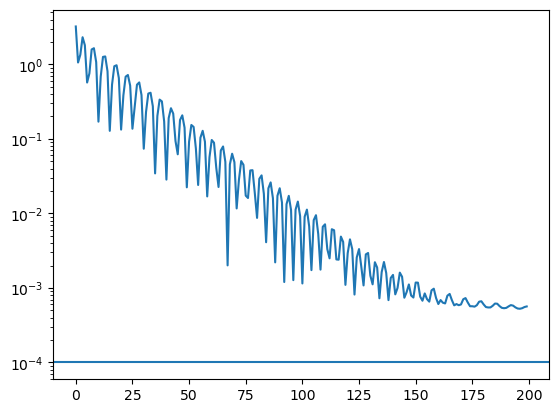

In [13]:
plt.semilogy(solver_dlra.residual[:200])
plt.axhline(1e-4)
